# Evaluación semántica — YOLO-Seg (segmentación de grietas)

Evalúa los modelos entrenados en `02_train.ipynb` (acá no se reentrena). Hay dos cosas a cuidar para que las métricas sean comparables con el resto del grupo:

Primero, el letterbox. Al inferir, Ultralytics trabaja sobre la imagen con padding (las imágenes verticales 544×384 lo necesitan). Si se reescala `result.masks.data` directo al tamaño original, se arrastra ese padding y la máscara queda corrida hacia abajo. En grietas de 2–5 px de ancho un corrimiento de ~10 px da IoU≈0 aunque la predicción se vea bien. Se resuelve con `retina_masks=True`, que ya devuelve las máscaras en coordenadas de la imagen original.

Segundo, qué número reportar. La comparación es por IoU de la clase grieta. El mIoU de 2 clases promedia también el fondo (que casi siempre da ~0.98) y queda inflado, así que no sirve para comparar. El IoU además cambia según se calcule por imagen (macro) o global (micro, acumulando intersección y unión sobre todo el test), y según la resolución. Se calculan todas las variantes para poder cruzar con cualquier forma de reporte del grupo.

## 1. Setup

Carga los `best.pt` ya entrenados. Son cuatro modelos: `nano`, `small` y `nano_dilated1` a imgsz=512, que comparten config y forman la comparación estricta, y `nano_hires` a imgsz=768, que al entrenar a otra resolución queda fuera de esa comparación y se reporta aparte (marcado con \*).

In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import Image, display
from ultralytics import YOLO

SEG_DIR = Path.cwd() / "runs" / "yolo_seg"
DATASETS = Path.cwd().parent.parent / "datasets"
TEST_IMAGES_DIR = DATASETS / "dataset_1000_yoloseg_fullpoly" / "test" / "images"
DEEPCRACK_TEST_LAB = DATASETS / "dataset_1000" / "test_lab"   # ground truth semántico real

test_files = sorted(TEST_IMAGES_DIR.glob("*.jpg"))
print(f"Test: {len(test_files)} imágenes")
print("CUDA:", torch.cuda.is_available())

# Modelos ya entrenados en 02_train.ipynb (no se reentrena nada acá)
MODELS = {
    "nano":          dict(run="yolo11n_seg_nano",     imgsz=512, estricto=True),
    "small":         dict(run="yolo11s_seg_small",    imgsz=512, estricto=True),
    "nano_dilated1": dict(run="yolo11n_seg_dilated1", imgsz=512, estricto=True),
    "nano_hires":    dict(run="yolo11n_seg_hires",    imgsz=768, estricto=False),  # mejora, fuera de la comparación estricta
}
for name, cfg in MODELS.items():
    w = SEG_DIR / cfg["run"] / "weights" / "best.pt"
    cfg["model"] = YOLO(str(w)) if w.exists() else None
    print(f"  {name:14s} imgsz={cfg['imgsz']}  {'OK' if cfg['model'] else 'FALTAN PESOS: ' + str(w)}")

# Ground truth cacheado (np.squeeze: imread a veces devuelve (H,W,1))
GT_MASKS = {}
for f in test_files:
    gt = np.squeeze(cv2.imread(str(DEEPCRACK_TEST_LAB / f"{f.stem}.png"), cv2.IMREAD_GRAYSCALE))
    GT_MASKS[f.stem] = gt > 127


Test: 237 imágenes
CUDA: True
  nano           imgsz=512  OK
  small          imgsz=512  OK
  nano_dilated1  imgsz=512  OK
  nano_hires     imgsz=768  OK


## 2. Inferencia y métricas

`predict_semantic_mask` usa `retina_masks=True`, así la máscara sale ya sin el padding del letterbox y alineada con el GT. `evaluate_pred_fn` calcula en una pasada:

- `iou_mean` / `iou_median`: IoU de grieta promediado por imagen (macro). Es la métrica principal.
- `iou_global`: IoU de grieta acumulando intersección y unión sobre todo el test (micro).
- `miou_2c`: mIoU de 2 clases (fondo + grieta) a resolución nativa.
- `miou_2c_512` / `iou_global_512`: lo mismo pero con predicción y GT resizeados a 512×512 nearest. Son las columnas a usar si el resto del grupo reporta el IoU global a 512.

In [2]:
def predict_semantic_mask(model, img_path, conf, imgsz):
    """Une las máscaras de instancia en una binaria (H, W) en resolución original."""
    r = model.predict(str(img_path), conf=conf, imgsz=imgsz, retina_masks=True, verbose=False)[0]
    h, w = r.orig_shape
    sem = np.zeros((h, w), dtype=bool)
    if r.masks is not None:
        for m in r.masks.data.cpu().numpy():
            m = np.squeeze(m)
            if m.shape != (h, w):
                m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
            sem |= m > 0.5
    return sem


def evaluate_pred_fn(pred_fn):
    """Evalúa una función img_path -> máscara binaria sobre todo el test."""
    per_image = []
    ic = uc = ib = ub = 0            # grieta / fondo a resolución nativa
    ic5 = uc5 = ib5 = ub5 = 0        # a 512×512
    tp = fp = fn = 0                 # grieta @512 (para precision/recall/F1 globales)
    for img_path in test_files:
        gt = GT_MASKS[img_path.stem]
        pred = pred_fn(img_path)
        i, u = (pred & gt).sum(), (pred | gt).sum()
        per_image.append((img_path, float("nan") if u == 0 else i / u))
        ic += i; uc += u
        ib += (~pred & ~gt).sum(); ub += (~pred | ~gt).sum()
        g5 = cv2.resize(gt.astype(np.uint8), (512, 512), interpolation=cv2.INTER_NEAREST) > 0
        p5 = cv2.resize(pred.astype(np.uint8), (512, 512), interpolation=cv2.INTER_NEAREST) > 0
        ic5 += (p5 & g5).sum(); uc5 += (p5 | g5).sum()
        ib5 += (~p5 & ~g5).sum(); ub5 += (~p5 | ~g5).sum()
        tp += (p5 & g5).sum(); fp += (p5 & ~g5).sum(); fn += (~p5 & g5).sum()
    ious = np.array([i for _, i in per_image]); valid = ~np.isnan(ious)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        "iou_mean": float(ious[valid].mean()),
        "iou_median": float(np.median(ious[valid])),
        "iou_global": ic / uc,
        "miou_2c": (ic / uc + ib / ub) / 2,
        "iou_global_512": ic5 / uc5,
        "miou_2c_512": (ic5 / uc5 + ib5 / ub5) / 2,
        "precision_512": float(precision),   # clase grieta, global @512
        "recall_512": float(recall),
        "f1_512": float(f1),
        "per_image": per_image,
    }


def evaluate_model(model, conf, imgsz):
    return evaluate_pred_fn(lambda p: predict_semantic_mask(model, p, conf, imgsz))

## 3. Barrido de confianza por modelo

El mejor `conf` depende del modelo, así que se barre por modelo y se elige el que
maximiza `iou_mean` (la métrica del TP).

In [3]:
CONFS = [0.25, 0.10, 0.05, 0.01]

sweep = {}     # sweep[nombre][conf] = métricas
best_conf = {} # mejor conf por modelo (por iou_mean)
for name, cfg in MODELS.items():
    if cfg["model"] is None:
        continue
    sweep[name] = {}
    for conf in CONFS:
        sweep[name][conf] = evaluate_model(cfg["model"], conf, cfg["imgsz"])
    best_conf[name] = max(CONFS, key=lambda c: sweep[name][c]["iou_mean"])
    fila = "  ".join(f"conf={c}: {sweep[name][c]['iou_mean']:.4f}" for c in CONFS)
    print(f"{name:14s} {fila}   -> mejor conf={best_conf[name]}")


nano           conf=0.25: 0.6122  conf=0.1: 0.6339  conf=0.05: 0.6381  conf=0.01: 0.6416   -> mejor conf=0.01
small          conf=0.25: 0.6101  conf=0.1: 0.6279  conf=0.05: 0.6389  conf=0.01: 0.6461   -> mejor conf=0.01
nano_dilated1  conf=0.25: 0.6041  conf=0.1: 0.6112  conf=0.05: 0.6122  conf=0.01: 0.5973   -> mejor conf=0.05
nano_hires     conf=0.25: 0.6534  conf=0.1: 0.6780  conf=0.05: 0.6844  conf=0.01: 0.6819   -> mejor conf=0.05


## 4. Tabla comparativa

Cada modelo en su mejor `conf`. La fila de referencia son los valores que reportó el compañero para su modelo semántico (IoU grieta 0.662, mIoU 0.8229), calculados global sobre máscaras 512×512, así que se comparan contra las columnas `*_512`.

In [4]:
rows = []
for name in sweep:
    m = sweep[name][best_conf[name]]
    estricto = MODELS[name]["estricto"]
    rows.append({
        "modelo": name if estricto else f"{name} *",   # * = fuera de la comparación estricta
        "comparacion": "estricta (512)" if estricto else "mejora (768)",
        "conf": best_conf[name],
        "iou_mean": round(m["iou_mean"], 4),
        "iou_global_512": round(m["iou_global_512"], 4),
        "miou_2c_512": round(m["miou_2c_512"], 4),
        "precision_512": round(m["precision_512"], 4),
        "recall_512": round(m["recall_512"], 4),
        "f1_512": round(m["f1_512"], 4),
    })

# Referencia: valores reportados por el compañero (global @512)
rows.append({"modelo": "ref. semántica grupo", "comparacion": "referencia", "conf": None,
             "iou_mean": None, "iou_global_512": 0.662, "miou_2c_512": 0.8229,
             "precision_512": None, "recall_512": None, "f1_512": None})

summary = pd.DataFrame(rows).sort_values("iou_global_512", ascending=False)
summary.to_csv(SEG_DIR / "comparison_final_eval.csv", index=False)
print(summary.to_string(index=False))
print()
print("Precision/Recall/F1 son de la clase grieta, globales (micro) a 512×512, comparables")
print("con iou_global_512. (*) nano_hires entrena a imgsz=768, fuera de la comparación estricta.")

              modelo    comparacion  conf  iou_mean  iou_global_512  miou_2c_512  precision_512  recall_512  f1_512
        nano_hires *   mejora (768)  0.05    0.6844          0.7026       0.8438         0.8580      0.7951  0.8254
               small estricta (512)  0.01    0.6461          0.6756       0.8295         0.8450      0.7711  0.8064
                nano estricta (512)  0.01    0.6416          0.6686       0.8259         0.8526      0.7560  0.8014
ref. semántica grupo     referencia   NaN       NaN          0.6620       0.8229            NaN         NaN     NaN
       nano_dilated1 estricta (512)  0.05    0.6122          0.6447       0.8117         0.7207      0.8593  0.7840

Precision/Recall/F1 son de la clase grieta, globales (micro) a 512×512, comparables
con iou_global_512. (*) nano_hires entrena a imgsz=768, fuera de la comparación estricta.


## 5. Muestras cualitativas (peor / mediana / mejor)

Con `retina_masks=True` la predicción queda alineada con el ground truth, así que el IoU
medido refleja lo que se ve en la máscara.

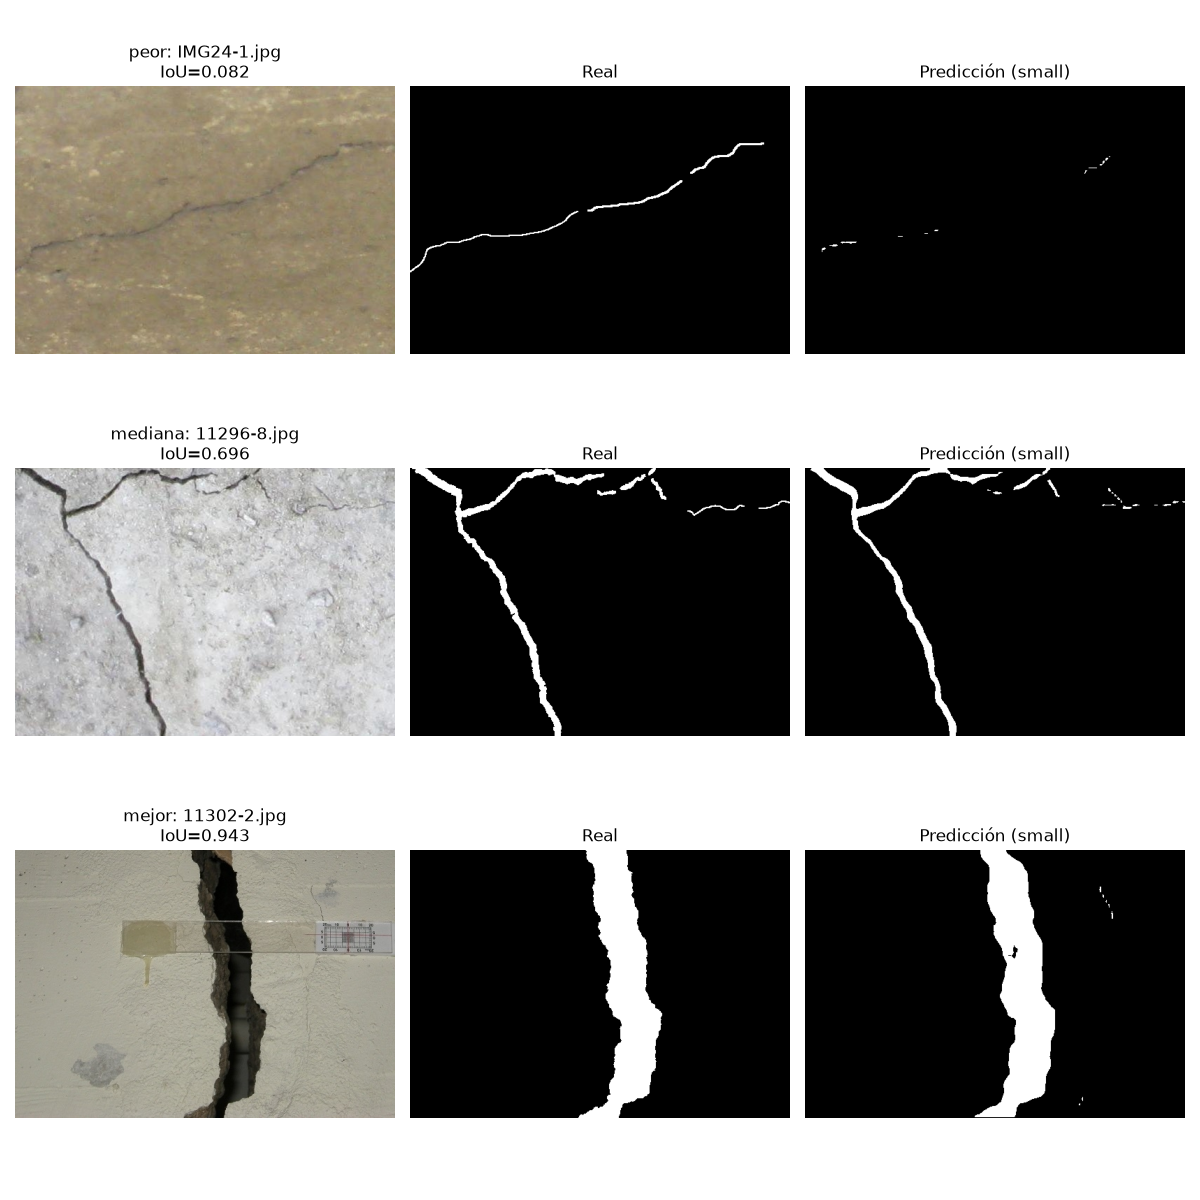

In [5]:
FIGURES_DIR = Path.cwd() / "figures"; FIGURES_DIR.mkdir(exist_ok=True)
estrictos = [n for n in sweep if MODELS[n]["estricto"]]
best_strict = max(estrictos, key=lambda n: sweep[n][best_conf[n]]["iou_mean"])
m = sweep[best_strict][best_conf[best_strict]]
per = sorted([(p, i) for p, i in m["per_image"] if not np.isnan(i)], key=lambda x: x[1])
picks = [per[0], per[len(per) // 2], per[-1]]; titles = ["peor", "mediana", "mejor"]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for row, ((img_path, iou_val), t) in enumerate(zip(picks, titles)):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    gt = GT_MASKS[img_path.stem]
    pred = predict_semantic_mask(MODELS[best_strict]["model"], img_path,
                                 best_conf[best_strict], MODELS[best_strict]["imgsz"])
    axes[row, 0].imshow(img);               axes[row, 0].set_title(f"{t}: {img_path.name}\nIoU={iou_val:.3f}")
    axes[row, 1].imshow(gt, cmap="gray");   axes[row, 1].set_title("Real")
    axes[row, 2].imshow(pred, cmap="gray"); axes[row, 2].set_title(f"Predicción ({best_strict})")
    for a in axes[row]: a.axis("off")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "semantic_samples_eval.png", dpi=100); plt.close(fig)
display(Image(str(FIGURES_DIR / "semantic_samples_eval.png")))

## Conclusión

- La comparación se hace sobre el IoU de la clase grieta, no sobre el mIoU de 2 clases: el mIoU promedia el fondo (~0.98) y da 0.8229 contra 0.662 de la referencia, sin aportar nada sobre la grieta.
- El `retina_masks=True` es lo que hace que el IoU medido coincida con lo que se ve: sin eso, imágenes bien predichas pero con la máscara corrida por el letterbox miden ≈0.
- Quedó sin probar desactivar `mosaic` (viene activo por default en Ultralytics); hacerlo implicaría reentrenar.